# 04 — End-to-end case study: an SBDC counselor's first session

**Module:** all three (`msmt.integrity`, `msmt.resilience`, `msmt.forecasting`) &nbsp;•&nbsp; **Companion to:** *Main Street Marketplace*, capstone post.

Imagine an SBDC counselor sitting down with a small marketplace seller for the first time. The seller has a year of daily history across roughly fifty SKUs. They sell on a national marketplace, their growth has plateaued, and they've started seeing periodic stockouts. They aren't sure where the leverage is.

This notebook is the diagnostic the counselor would run in that first session. We use the toolkit's three modules in the order a real conversation tends to flow:

1. **Integrity** — *is the listing/operational profile in good shape?* The answer scopes everything that follows.
2. **Resilience** — *which SKUs are most at risk of stocking out this week?* That's the urgent operational triage.
3. **Forecasting + guardrails** — *can we trust a forecast for those at-risk SKUs to drive the next reorder?*

All inputs are **synthetic** so the notebook is fully reproducible. Replacing the synthetic catalog with a real seller-portal export is a one-line change.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from msmt.data import generate_seller_data
from msmt.integrity import (
    compute_scorecard, scorecard_for_synthetic_seller,
    concentration_audit,
)
from msmt.resilience import stockout_heatmap_data
from msmt.forecasting import run_forecast, run_guardrails

SEED = 42
catalog = generate_seller_data(n_skus=50, n_days=365, seed=SEED)
print(f"Catalog: {len(catalog):,} rows, "
      f"{catalog['sku_id'].nunique()} SKUs across "
      f"{catalog['category'].nunique()} categories")


Importing plotly failed. Interactive plots will not work.


Catalog: 18,250 rows, 50 SKUs across 8 categories


## Stage 1 — Integrity check

Before talking inventory or forecasting, we score the seller's operational profile. A seller whose listings are at risk of marketplace suppression has a different problem than one whose listings are healthy but whose stock isn't keeping up. We use the synthetic-seller helper to stand in for what would normally come from the seller's performance dashboard.

In [2]:
scorecard = scorecard_for_synthetic_seller(seed=SEED)
print(f"Overall integrity score: {scorecard['overall_score']:.1f} / 100")
print(f"Suppression risk:         {scorecard['suppression_risk'].upper()}")
print()
print('Top issues to fix:')
for issue, rec in zip(scorecard['top_issues'], scorecard['recommendations']):
    print(f"  \u2022 {issue['plain_english']}")
    print(f"    \u2192 {rec}")


Overall integrity score: 75.0 / 100
Suppression risk:         LOW

Top issues to fix:
  • Pre Fulfillment Cancel Rate is poor (score 0/100).
    → You are cancelling too many orders before shipment, usually a sign of stockouts the catalog didn't reflect. Plug msmt.resilience reorder-point output into your reorder workflow to cut these.
  • Return Rate is poor (score 0/100).
    → Your return rate is elevated. High returns signal listing-reality mismatch to the algorithm. Audit your top-returned SKUs for image accuracy and description completeness.


Whether or not the integrity score lands in the safe zone, the *top issues* table tells the counselor where the easy lifts are. These are typically a 1–2 week conversation: tighten handling-time settings, add product images, run the listing-quality report.

We also run the **catalog concentration** audit so we know whether the seller's volume is dangerously concentrated in a few SKUs — that informs the resilience triage in Stage 2.

In [3]:
audit = concentration_audit(catalog)
print(audit['audit_narrative'])
print()
audit['summary_df'].round(2)


Of 8 categories, 4 show high concentration (HHI > 2,500 — the DOJ threshold for "highly concentrated" markets in merger review): Office Products, Pet Supplies, Beauty & Personal Care, Health & Household. The average HHI across the catalog is 2,476. The seller is exposed to single-SKU outage risk in those categories and should consider diversifying volume across additional SKUs before scaling.



,category,hhi,concentration_level,top_seller_share,seller_count
0,Office Products,4363.25,high,0.47,4
1,Pet Supplies,3338.98,high,0.36,4
2,Beauty & Personal Care,3132.81,high,0.37,5
3,Health & Household,3102.52,high,0.34,5
4,Home & Kitchen,1593.45,moderate,0.19,9
5,Outdoors,1441.21,low,0.16,7
6,Arts & Crafts,1422.44,low,0.16,8
7,Toys & Games,1417.03,low,0.16,8


## Stage 2 — Stockout-risk triage

Now we point the resilience module at the catalog. It runs the same pipeline a counselor would walk through manually: classify each SKU's demand pattern, pick the right safety-stock method, compute a reorder point, and score the SKU's current exposure to stockout against that reorder point.

The output is one ranked row per SKU. The top of the list is where the counselor's attention goes first.

In [4]:
heatmap = stockout_heatmap_data(catalog, service_level=0.95)
show_cols = [
    'sku_id', 'pattern', 'method_used', 'rop', 'safety_stock',
    'current_stock', 'risk_score', 'risk_level', 'days_until_stockout',
]
print('Top 10 most at-risk SKUs:')
heatmap[show_cols].head(10).round(2)


Top 10 most at-risk SKUs:


,sku_id,pattern,method_used,rop,safety_stock,current_stock,risk_score,risk_level,days_until_stockout
0,SKU-IM-0045,intermittent,intermittent,77.67,71.43,7.0,1.00,critical,14.00
1,SKU-IM-0043,intermittent,intermittent,109.44,98.12,19.0,1.00,critical,21.81
2,SKU-NS-0048,new_sku,normal,19.96,12.75,4.0,1.00,critical,0.63
3,SKU-IM-0041,intermittent,intermittent,278.51,257.70,59.0,0.99,critical,103.25
4,SKU-IM-0039,intermittent,intermittent,215.85,196.95,46.0,0.98,critical,117.09
5,SKU-IM-0042,intermittent,intermittent,256.07,237.72,67.0,0.92,critical,144.31
6,SKU-IM-0040,intermittent,intermittent,221.63,199.36,61.0,0.91,critical,58.90
7,SKU-WS-0022,weekly_seasonal,normal,455.12,78.23,292.0,0.45,medium,18.25
8,SKU-SM-0015,smooth,normal,180.76,35.36,124.0,0.39,medium,12.67
9,SKU-NS-0050,new_sku,normal,42.20,21.62,29.0,0.39,medium,3.62


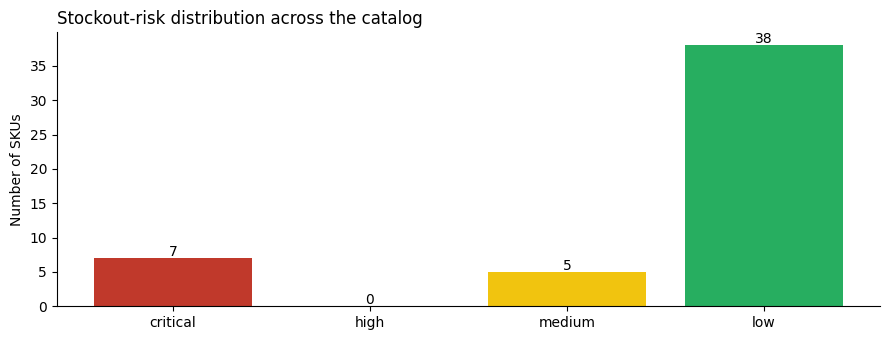

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
level_color = {'critical': '#c0392b', 'high': '#e67e22',
               'medium': '#f1c40f', 'low': '#27ae60'}
counts = heatmap['risk_level'].value_counts().reindex(
    ['critical', 'high', 'medium', 'low']
).fillna(0).astype(int)
ax.bar(counts.index, counts.values, color=[level_color[l] for l in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(int(v)), ha='center', fontsize=10)
ax.set_ylabel('Number of SKUs')
ax.set_title('Stockout-risk distribution across the catalog', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## Stage 3 — Forecast the most at-risk SKUs

For the SKUs that need a reorder, the next question is: *can we trust a forecast to size the order?* We run the auto-selected forecasting method on each of the top three highest-risk SKUs and wrap the result in the five guardrails. If the guardrails come back clean, the counselor reorders to the forecast. If multiple fire, the counselor falls back to a trailing average and revisits in a week.

In [6]:
top_at_risk = heatmap.head(3)['sku_id'].tolist()
forecasts = []
reports = []
for sku_id in top_at_risk:
    sub = catalog[catalog['sku_id'] == sku_id]
    fc = run_forecast(sub, horizon=28)
    proposed = float(sub['units_sold'].tail(30).mean()) * 30  # ~30 days of stock
    rep = run_guardrails(sub, fc, proposed_order_qty=proposed)
    forecasts.append(fc)
    reports.append(rep)
    print(f"{sku_id}  pattern={fc['pattern']:18s}  method={fc['method_used']:16s}  "
          f"any_fired={rep['any_fired']}")


SKU-IM-0045  pattern=intermittent        method=croston           any_fired=True
SKU-IM-0043  pattern=intermittent        method=croston           any_fired=True


SKU-NS-0048  pattern=new_sku             method=moving_average    any_fired=True


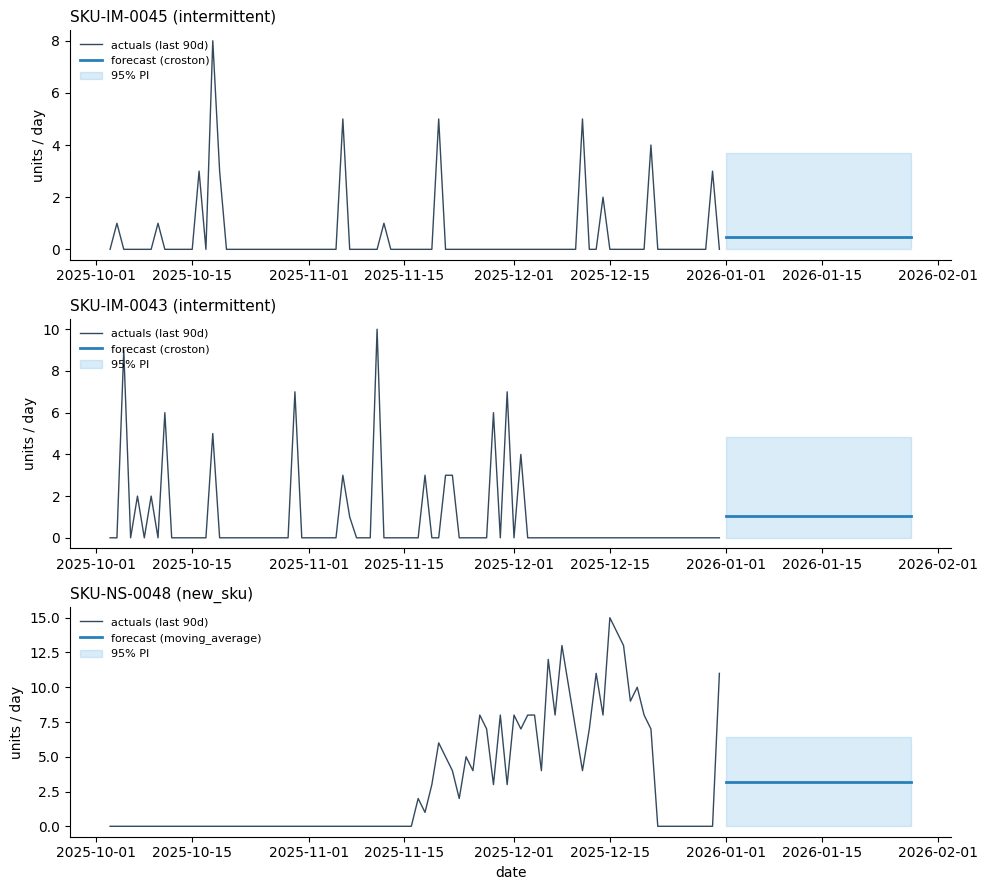

In [7]:
fig, axes = plt.subplots(len(forecasts), 1, figsize=(10, 3.0 * len(forecasts)))
if len(forecasts) == 1:
    axes = [axes]
for ax, fc in zip(axes, forecasts):
    sub = catalog[catalog['sku_id'] == fc['sku_id']].sort_values('date')
    history = sub.tail(90)
    ax.plot(history['date'], history['units_sold'], color='#34495e',
            linewidth=1.0, label='actuals (last 90d)')
    ax.plot(fc['horizon_dates'], fc['forecast'], color='#2980b9',
            linewidth=2.0, label=f"forecast ({fc['method_used']})")
    ax.fill_between(fc['horizon_dates'], fc['lower_95'], fc['upper_95'],
                    color='#3498db', alpha=0.18, label='95% PI')
    ax.set_title(f"{fc['sku_id']} ({fc['pattern']})", loc='left', fontsize=11)
    ax.set_ylabel('units / day')
    ax.legend(frameon=False, loc='upper left', fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[-1].set_xlabel('date')
plt.tight_layout(); plt.show()


### Guardrail reports for each at-risk SKU

The guardrails are what turn a forecast into a *recommendation*. If the column shows multiple FIRED entries on a SKU, the counselor's call is: don't auto-reorder, fall back to a trailing average, recheck in a week.

In [8]:
rows = []
for rep in reports:
    for name, g in rep['guardrails'].items():
        if name == 'degradation':
            status = f"L{g.get('fallback_level')}/{g.get('method_name')}"
        else:
            status = 'FIRED' if g.get('fired') else 'ok'
        rows.append({
            'sku_id': rep['sku_id'],
            'guardrail': name,
            'status': status,
        })
guardrail_table = pd.DataFrame(rows).pivot(
    index='sku_id', columns='guardrail', values='status'
)
guardrail_table


guardrail,cap,confidence,degradation,drift,regime
sku_id,,,,,
SKU-IM-0043,FIRED,FIRED,L1/primary,FIRED,ok
SKU-IM-0045,FIRED,FIRED,L1/primary,FIRED,ok
SKU-NS-0048,FIRED,FIRED,L1/primary,ok,ok


## What goes in the counselor's write-up

By the end of the session, the counselor walks away with three concrete artifacts to send the seller:

1. **Integrity action list** — the 1–3 top-issue recommendations from Stage 1, phrased as a one-week to-do list.
2. **Reorder list** — the critical and high-risk SKUs from Stage 2, sized using the reorder points the toolkit computed (and padded with safety stock for any SKUs whose guardrails fired).
3. **Forecast confidence note** — for each reordered SKU, whether the forecast is trustworthy enough to size to or whether the counselor recommended a smaller, more conservative order pending another week of data.

Everything in this notebook came from synthetic data, but the exact same code runs on a real seller-portal export. The minimum schema the toolkit expects — `date`, `sku_id`, `units_sold`, `stock_on_hand`, `lead_time_days`, `category` — is what every major marketplace's CSV export already produces.